# 🧬 Sozo Lattice Foundation — Training Pipeline
**Version:** `lattice_v1.0_2026_02`  
**Datasets:** QM9 (134k) + ZINC250k (250k) — real schemas, real column names  
**Architecture:** GATv2Conv MPNN + Global Attention Pooling  
**Targets:** `durability_score` (proxy: bond energy) + `sustainability_score` (proxy: biodegradability)  

---
### How to add datasets on Kaggle
Before running: click **+ Add Data** (right panel) and add:
1. `zaharch/quantum-machine-9-aka-qm9` — QM9 dataset
2. `basu369victor/zinc250k` — ZINC250k dataset

### Real column schemas used here
| Dataset | SMILES column | Property columns |
|---|---|---|
| QM9 | `SMILES1` | `homo`, `lumo`, `gap`, `U0`, `Cv`, `mu`, `alpha` |
| ZINC250k | `smiles` | `logP`, `qed`, `SAS` |

### Proxy mapping (no lab labels yet)
| Sozo target | Proxy formula | Rationale |
|---|---|---|
| `durability_score` | `norm(-U0) × 100` | Atomization energy: stronger bonds = more durable |
| `sustainability_score` | `norm(gap) × 0.6 + norm(-SAS) × 0.4` | Large gap = stable/inert; low SAS = synthesizable/degradable |

## Phase 0 — Environment Setup

In [1]:
import subprocess, sys

def pip(cmd):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + cmd.split())

pip('rdkit')

import torch
tv   = torch.__version__.split('+')[0]
cuda = torch.version.cuda.replace('.', '')       # e.g. '121'
base = f'https://data.pyg.org/whl/torch-{tv}+cu{cuda}.html'
print(f'Torch: {tv}  |  CUDA: cu{cuda}')
print(f'PyG wheel: {base}')

pip('torch-geometric')
#pip(f'torch-scatter -f {base}')
#pip(f'torch-sparse  -f {base}')

print('✅ Environment ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 56.6 MB/s eta 0:00:00
Torch: 2.10.0  |  CUDA: cu128
PyG wheel: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.4 MB/s eta 0:00:00
✅ Environment ready


In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, GlobalAttention

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Phase 1 — Data Ingestion

### QM9 schema
- File: `/kaggle/input/quantum-machine-9-aka-qm9/qm9.csv`
- SMILES: `SMILES1` (canonical) or `SMILES2` (relaxed geometry)
- 133,885 molecules after removing uncharacterized ones
- All molecules contain only C, H, O, N, F — max 9 heavy atoms

### ZINC250k schema
- File: `/kaggle/input/zinc250k/250k_rndm_zinc_drugs_clean_3.csv`
- SMILES: `smiles`
- Properties: `logP` (solubility), `qed` (drug-likeness 0–1), `SAS` (synthetic accessibility 1–10)
- 249,455 molecules with MW up to ~500 Da

In [3]:
# ── QM9 — exact file path and column names ─────────────────────────────────
# Kaggle dataset slug: zaharch/quantum-machine-9-aka-qm9
# After adding the dataset, the file appears at this path:
import os
#QM9_PATH = '/kaggle/input/datasets/zaharch/quantum-machine-9-aka-qm9/qm9.csv'

# ── Exact QM9 column reference ──────────────────────────────────────────────
# Column   | Unit      | Description
# ---------|-----------|------------------------------------------
# SMILES1  | —         | SMILES from original xyz file
# SMILES2  | —         | SMILES from relaxed geometry (use this)
# A        | GHz       | Rotational constant A
# B        | GHz       | Rotational constant B
# C        | GHz       | Rotational constant C
# mu       | Debye     | Dipole moment
# alpha    | a0^3      | Isotropic polarizability
# homo     | Hartree   | Energy of HOMO
# lumo     | Hartree   | Energy of LUMO
# gap      | Hartree   | HOMO-LUMO gap  ← stability proxy
# r2       | a0^2      | Electronic spatial extent
# zpve     | Hartree   | Zero point vibrational energy
# U0       | Hartree   | Internal energy at 0K  ← bond strength proxy
# U        | Hartree   | Internal energy at 298K
# H        | Hartree   | Enthalpy at 298K
# G        | Hartree   | Free energy at 298K
# Cv       | cal/molK  | Heat capacity at 298K  ← thermal durability proxy

# ── QM9 — Parse from individual .xyz files ──────────────────────────────────

import os, glob
import pandas as pd
from multiprocessing.pool import ThreadPool

QM9_DIR = '/kaggle/input/datasets/zaharch/quantum-machine-9-aka-qm9/dsgdb9nsd.xyz'

PROP_NAMES = ['A','B','C','mu','alpha','homo','lumo','gap','r2','zpve','U0','U','H','G','Cv']

def parse_qm9_xyz(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        n_atoms = int(lines[0].strip())
        line1 = lines[1].strip().replace('*^', 'e')
        parts = line1.split()
        props = {'mol_id': int(parts[1])}
        for i, name in enumerate(PROP_NAMES):
            props[name] = float(parts[i + 2])
        smiles_line = lines[n_atoms + 3].strip().replace('*^', 'e').split('\t')
        props['SMILES1'] = smiles_line[0].strip()
        props['SMILES2'] = smiles_line[1].strip() if len(smiles_line) > 1 else smiles_line[0].strip()
        return props
    except Exception:
        return None

files = sorted(glob.glob(os.path.join(QM9_DIR, '*.xyz')))
print(f'Found {len(files):,} xyz files — parsing with 8 threads...')

with ThreadPool(8) as pool:
    results = pool.map(parse_qm9_xyz, files)

records = [r for r in results if r is not None]
print(f'Parsed: {len(records):,} ok | {len(files)-len(records)} skipped')

qm9_raw = pd.DataFrame(records)
print(f'Columns: {list(qm9_raw.columns)}')
print(qm9_raw[['SMILES1','SMILES2','homo','lumo','gap','U0','Cv']].head(3))

Found 133,885 xyz files — parsing with 8 threads...
Parsed: 133,885 ok | 0 skipped
Columns: ['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'U0', 'U', 'H', 'G', 'Cv', 'SMILES1', 'SMILES2']
  SMILES1 SMILES2    homo    lumo     gap         U0     Cv
0       C       C -0.3877  0.1171  0.5048 -40.478930  6.469
1       N       N -0.2570  0.0829  0.3399 -56.525887  6.316
2       O       O -0.2928  0.0687  0.3615 -76.404702  6.002


In [4]:
# ── ZINC250k — exact file path and column names ─────────────────────────────
# Kaggle dataset slug: basu369victor/zinc250k
# The file inside is named: 250k_rndm_zinc_drugs_clean_3.csv
ZINC_PATH = '/kaggle/input/datasets/basu369victor/zinc250k/250k_rndm_zinc_drugs_clean_3.csv'

# ── Exact ZINC250k column reference ─────────────────────────────────────────
# Column  | Range  | Description
# --------|--------|------------------------------------------
# smiles  | —      | SMILES string  ← note: lowercase
# logP    | varies | Water-octanol partition coefficient (solubility proxy)
#         |        | Higher logP = more hydrophobic = less biodegradable
# qed     | 0–1    | Quantitative Estimate of Drug-likeness
#         |        | 1 = ideal, 0 = poor — proxy for molecular quality
# SAS     | 1–10   | Synthetic Accessibility Score
#         |        | 1 = easy to make, 10 = hard — proxy for synthesizability
#         |        | Low SAS = more likely to be manufacturable/degradable

if os.path.exists(ZINC_PATH):
    zinc_raw = pd.read_csv(ZINC_PATH)
    print(f'ZINC250k loaded: {len(zinc_raw):,} molecules')
    print(f'Columns: {list(zinc_raw.columns)}')
    print(zinc_raw[['smiles', 'logP', 'qed', 'SAS']].head(3))
else:
    print('ZINC250k file not found — check dataset was added')
    print(f'Expected: {ZINC_PATH}')
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if f.endswith('.csv'):
                print(f'  Found: {os.path.join(root, f)}')

ZINC250k loaded: 249,455 molecules
Columns: ['smiles', 'logP', 'qed', 'SAS']
                                              smiles     logP       qed  \
0          CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n  5.05060  0.702012   
1     C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n  3.11370  0.928975   
2  N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...  4.96778  0.599682   

        SAS  
0  2.084095  
1  3.432004  
2  2.470633  


## Phase 1b — Label Engineering

QM9 and ZINC250k don't have `tensile_strength` or `biodegradability` columns — those are lab measurements that don't exist at this scale yet. We construct **proxy targets** from the available quantum/chemical properties.

### Durability proxy — from QM9 `U0` (atomization energy)
U0 is the internal energy at 0K in Hartree. More negative = stronger total bonding = higher structural integrity.  
We negate and normalize to [0, 100].

### Sustainability proxy — composite
**For QM9:** `0.6 × norm(gap) + 0.4 × norm(Cv)`  
Large HOMO-LUMO gap = chemically stable/inert = doesn't leach harmful compounds.  
Low heat capacity Cv = simpler molecular motion = less complex degradation pathway.

**For ZINC250k:** `0.5 × norm(-logP) + 0.3 × norm(qed) + 0.2 × norm(11 - SAS)`  
Low logP = hydrophilic = more water-soluble = more biodegradable.  
High qed = drug-like = well-understood degradation profile.  
Low SAS = simple synthesis = simpler degradation.

> **Important:** These are informed proxies, not ground truth. The model trained here is a Stage 0 foundation. In Stage 3, you replace these with real lab measurements — tensile testing data, OECD biodegradation assay results. At that point the proxies get discarded and the model learns from physical reality.

In [5]:
def minmax_norm(series: pd.Series) -> pd.Series:
    """Normalize a series to [0, 1]. Clips outliers at 1st/99th percentile first."""
    lo = series.quantile(0.01)
    hi = series.quantile(0.99)
    clipped = series.clip(lo, hi)
    denom = hi - lo
    if denom == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (clipped - lo) / denom


def engineer_qm9_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build durability_score and sustainability_score from QM9 properties.
    Input columns required: U0, gap, Cv
    Output columns added:   durability_score [0-100], sustainability_score [0-1]
    """
    # Durability: negate U0 (more negative raw = stronger bonds = higher durability)
    df['durability_score'] = minmax_norm(-df['U0']) * 100.0

    # Sustainability: large gap (stable) + moderate Cv (simple thermal behaviour)
    # Negate Cv because lower heat capacity = simpler degradation
    sus = 0.6 * minmax_norm(df['gap']) + 0.4 * minmax_norm(-df['Cv'])
    df['sustainability_score'] = sus.clip(0, 1)

    return df


def engineer_zinc_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build durability_score and sustainability_score from ZINC250k properties.
    Input columns required: logP, qed, SAS
    Output columns added:   durability_score [0-100], sustainability_score [0-1]
    """
    # ZINC has no direct bond-strength proxy — use logP as structural complexity proxy
    # Higher logP = more hydrophobic = typically denser aromatic structure = more durable
    df['durability_score'] = minmax_norm(df['logP']) * 100.0

    # Sustainability: low logP (hydrophilic/biodegradable) + high qed + low SAS
    sus = (
        0.5 * minmax_norm(-df['logP']) +   # negative logP = more water-soluble
        0.3 * minmax_norm(df['qed'])    +   # high qed = well-characterised molecule
        0.2 * minmax_norm(11 - df['SAS'])   # 11-SAS inverts so low SAS → high score
    )
    df['sustainability_score'] = sus.clip(0, 1)

    return df

In [6]:
# ── Build unified DataFrame ────────────────────────────────────────────────
# Standardise to: smiles | durability_score | sustainability_score | source

frames = []

# --- QM9 ---
if 'qm9_raw' in dir() and qm9_raw is not None:
    qm9 = qm9_raw.copy()

    # Use SMILES2 (relaxed geometry) — more stable representation
    # Fall back to SMILES1 if SMILES2 column is absent
    smiles_col = 'SMILES2' if 'SMILES2' in qm9.columns else 'SMILES1'
    qm9 = qm9.rename(columns={smiles_col: 'smiles'})

    # Drop rows with missing required properties
    required_qm9 = ['smiles', 'U0', 'gap', 'Cv']
    qm9 = qm9.dropna(subset=required_qm9)

    qm9 = engineer_qm9_labels(qm9)
    qm9['source'] = 'qm9'
    qm9['recycled_content_pct'] = 0.0   # QM9 has no recipe metadata — use 0 as default
    qm9['fiber_additive_pct']   = 0.0

    frames.append(qm9[['smiles', 'durability_score', 'sustainability_score',
                        'recycled_content_pct', 'fiber_additive_pct', 'source']])
    print(f'QM9:     {len(qm9):>7,} molecules')
    print(f'  durability    — mean: {qm9.durability_score.mean():.1f}  std: {qm9.durability_score.std():.1f}')
    print(f'  sustainability — mean: {qm9.sustainability_score.mean():.3f}  std: {qm9.sustainability_score.std():.3f}')

# --- ZINC250k ---
if 'zinc_raw' in dir() and zinc_raw is not None:
    zinc = zinc_raw.copy()

    # ZINC250k column is lowercase 'smiles'
    required_zinc = ['smiles', 'logP', 'qed', 'SAS']
    zinc = zinc.dropna(subset=required_zinc)

    zinc = engineer_zinc_labels(zinc)
    zinc['source'] = 'zinc250k'
    zinc['recycled_content_pct'] = 0.0
    zinc['fiber_additive_pct']   = 0.0

    frames.append(zinc[['smiles', 'durability_score', 'sustainability_score',
                         'recycled_content_pct', 'fiber_additive_pct', 'source']])
    print(f'ZINC250k:{len(zinc):>7,} molecules')
    print(f'  durability    — mean: {zinc.durability_score.mean():.1f}  std: {zinc.durability_score.std():.1f}')
    print(f'  sustainability — mean: {zinc.sustainability_score.mean():.3f}  std: {zinc.sustainability_score.std():.3f}')

# Fallback: use synthetic seed data if neither dataset was added yet
if not frames:
    print('⚠️  No real datasets found — using synthetic seed data for pipeline validation')
    SEED = [
        ('CC(=O)Oc1ccccc1C(=O)O',       72.4, 0.85, 0.40, 0.05, 'seed'),
        ('[O-]C(=O)c1ccccc1',            58.1, 0.62, 0.25, 0.10, 'seed'),
        ('C(C(=O)O)N',                   45.3, 0.91, 0.60, 0.00, 'seed'),
        ('OC(=O)c1ccc(O)cc1',            67.8, 0.77, 0.35, 0.08, 'seed'),
        ('CC(C)CC(N)C(=O)O',             51.2, 0.88, 0.50, 0.03, 'seed'),
        ('c1ccc2ccccc2c1',               95.6, 0.30, 0.10, 0.15, 'seed'),
        ('OCC(O)CO',                     38.7, 0.95, 0.75, 0.00, 'seed'),
        ('CC(=O)NCCC1=CNc2ccc(O)cc21',   83.2, 0.55, 0.20, 0.12, 'seed'),
        ('C1CCCCC1',                     61.0, 0.42, 0.15, 0.07, 'seed'),
        ('OC(=O)CC(O)(CC(=O)O)C(=O)O',  44.5, 0.93, 0.65, 0.02, 'seed'),
    ]
    frames.append(pd.DataFrame(SEED, columns=[
        'smiles', 'durability_score', 'sustainability_score',
        'recycled_content_pct', 'fiber_additive_pct', 'source'
    ]))

df = pd.concat(frames, ignore_index=True)
print(f'\nCombined dataset: {len(df):,} molecules total')
df.head()

QM9:     133,885 molecules
  durability    — mean: 54.9  std: 20.2
  sustainability — mean: 0.511  std: 0.142
ZINC250k:249,455 molecules
  durability    — mean: 59.4  std: 21.2
  sustainability — mean: 0.533  std: 0.123

Combined dataset: 383,340 molecules total


,smiles,durability_score,sustainability_score,recycled_content_pct,fiber_additive_pct,source
0,C,0.0,1.000000,0.0,0.0,qm9
1,N,0.0,0.987976,0.0,0.0,qm9
2,O,0.0,1.000000,0.0,0.0,qm9
3,C#C,0.0,0.973178,0.0,0.0,qm9
4,C#N,0.0,1.000000,0.0,0.0,qm9


## Phase 2 — RDKit Validation + Graph Construction

In [7]:
def validate_smiles(smi):
    """Returns RDKit Mol if valid and sanitizable, else None."""
    if not isinstance(smi, str) or not smi.strip():
        return None
    try:
        mol = Chem.MolFromSmiles(smi.strip())
        if mol is None:
            return None
        Chem.SanitizeMol(mol)
        return mol
    except Exception:
        return None

df['mol'] = df['smiles'].apply(validate_smiles)
n_before = len(df)
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(f'Validation: {len(df):,} valid / {n_before:,} total  ({n_before - len(df):,} dropped)')
print(f'Sources: {df.source.value_counts().to_dict()}')

Validation: 382,594 valid / 383,340 total  (746 dropped)
Sources: {'zinc250k': 249455, 'qm9': 133139}


In [8]:
from rdkit.Chem import rdchem

HYBRIDIZATION_MAP = {
    rdchem.HybridizationType.SP:    0,
    rdchem.HybridizationType.SP2:   1,
    rdchem.HybridizationType.SP3:   2,
    rdchem.HybridizationType.SP3D:  3,
    rdchem.HybridizationType.SP3D2: 4,
    rdchem.HybridizationType.OTHER: 5,
}

BOND_TYPE_MAP = {
    rdchem.BondType.SINGLE:   0,
    rdchem.BondType.DOUBLE:   1,
    rdchem.BondType.TRIPLE:   2,
    rdchem.BondType.AROMATIC: 3,
}

NODE_FEATURE_DIM = 10
EDGE_FEATURE_DIM = 6

def atom_features(atom):
    """9-dim node feature vector."""
    hyb = [0] * 6
    hyb[HYBRIDIZATION_MAP.get(atom.GetHybridization(), 5)] = 1
    return [
        atom.GetAtomicNum(),
        *hyb,
        atom.GetTotalValence(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
    ]

def bond_features(bond):
    """6-dim edge feature vector."""
    bt = [0] * 4
    bt[BOND_TYPE_MAP.get(bond.GetBondType(), 0)] = 1
    return [
        *bt,
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]

def mol_to_graph(row) -> Data:
    mol = row['mol']

    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()],
        dtype=torch.float
    )

    edge_idx, edge_att = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_idx += [[i, j], [j, i]]
        edge_att += [bf, bf]

    if edge_idx:
        edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_att, dtype=torch.float)
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 6), dtype=torch.float)

    global_feat = torch.tensor(
        [[float(row['recycled_content_pct']), float(row['fiber_additive_pct'])]],
        dtype=torch.float
    )

    y = torch.tensor(
        [[float(row['durability_score']), float(row['sustainability_score'])]],
        dtype=torch.float
    )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        global_feat=global_feat,
        y=y
    )

# Build graph dataset
print('Building graph tensors...')
dataset = []
errors  = 0
for _, row in df.iterrows():
    try:
        dataset.append(mol_to_graph(row))
    except Exception:
        errors += 1

print(f'✅ {len(dataset):,} graphs built  ({errors} errors)')

# Inspect one graph
g = dataset[0]
print(f'Sample: nodes={g.x.shape} | edges={g.edge_index.shape} | y={g.y}')

Building graph tensors...
✅ 382,594 graphs built  (0 errors)
Sample: nodes=torch.Size([1, 10]) | edges=torch.Size([2, 0]) | y=tensor([[0., 1.]])


In [12]:
train_data, val_data = train_test_split(dataset, test_size=0.15, random_state=42)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=128, shuffle=False, num_workers=2)
print(f'Train: {len(train_data):,}  Val: {len(val_data):,}')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Train: 325,204  Val: 57,390
Train batches: 2541  Val batches: 449


## Phase 3 — Model Architecture

In [17]:
class SozoLatticeNet(nn.Module):
    """
    GATv2Conv MPNN + Global Attention Pooling.
    Outputs: [durability_score, sustainability_score]
    Supports Monte Carlo Dropout inference.
    """
    def __init__(
        self,
        node_in_dim:   int   = NODE_FEATURE_DIM,
        edge_in_dim:   int   = EDGE_FEATURE_DIM,
        global_in_dim: int   = 2,
        hidden_dim:    int   = 128,
        num_layers:    int   = 4,
        heads:         int   = 4,
        dropout:       float = 0.3,
        out_dim:       int   = 2,
    ):
        super().__init__()
        self.dropout_rate = dropout
        self.node_proj    = nn.Linear(node_in_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(num_layers):
            in_ch = hidden_dim * heads if i > 0 else hidden_dim
            self.convs.append(GATv2Conv(
                in_channels=in_ch, out_channels=hidden_dim,
                heads=heads, edge_dim=edge_in_dim,
                dropout=dropout, concat=True,
            ))
            self.norms.append(nn.LayerNorm(hidden_dim * heads))

        gat_out = hidden_dim * heads
        gate    = nn.Sequential(
            nn.Linear(gat_out, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1)
        )
        self.pool = GlobalAttention(gate_nn=gate)

        mlp_in = gat_out + global_in_dim
        self.head = nn.Sequential(
            nn.Linear(mlp_in, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64),    nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, out_dim)
        )

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        batch = (
            data.batch if hasattr(data, 'batch') and data.batch is not None
            else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        )
        h = F.relu(self.node_proj(x))
        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, ei, edge_attr=ea)
            h = norm(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout_rate, training=self.training)

        h_graph  = self.pool(h, batch)
        gctx     = data.global_feat
        if gctx.dim() == 3:
            gctx = gctx.squeeze(1)
        return self.head(torch.cat([h_graph, gctx], dim=-1))


model = SozoLatticeNet()

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}')
    model = torch.nn.DataParallel(model)

model = SozoLatticeNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SozoLatticeNet | Parameters: {n_params:,}')
print(f'Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0)}')

Using 2 GPUs: ['Tesla T4', 'Tesla T4']
SozoLatticeNet | Parameters: 1,944,131
Device: cuda | GPU: Tesla T4


## Phase 4 — Training

In [20]:
class JointLoss(nn.Module):
    """
    L = w1 × MSE(durability) + w2 × MSE(sustainability)
    w2 > w1: Earth-safety-first principle encoded in the objective.

    Note on scale: durability_score is [0,100] and sustainability_score is [0,1].
    To avoid durability dominating the loss, we scale durability MSE by 1/100^2.
    """
    def __init__(self, w1: float = 0.4, w2: float = 0.6):
        super().__init__()
        self.w1  = w1
        self.w2  = w2
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        # Normalise durability to [0,1] for loss balance
        l_dur = self.mse(pred[:, 0] / 100.0, target[:, 0] / 100.0)
        l_sus = self.mse(pred[:, 1],          target[:, 1])
        total = self.w1 * l_dur + self.w2 * l_sus
        return total, l_dur, l_sus


NUM_EPOCHS  = 50
criterion   = JointLoss(w1=0.4, w2=0.6)
optimizer   = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler   = OneCycleLR(
    optimizer,
    max_lr       = 3e-3,
    total_steps  = NUM_EPOCHS * len(train_loader),
    pct_start    = 0.3,
    anneal_strategy = 'cos',
)
print(f'Training for {NUM_EPOCHS} epochs  |  {NUM_EPOCHS * len(train_loader):,} total steps')

Training for 50 epochs  |  127,050 total steps


In [21]:
from tqdm.auto import tqdm

history  = {'train': [], 'val': [], 'l_dur': [], 'l_sus': []}
best_val = float('inf')

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc='Epochs', unit='ep')

for epoch in epoch_bar:

    # — Train —
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred   = model(batch)
        target = batch.y.view(-1, 2)
        loss, ld, ls = criterion(pred, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    # — Validate —
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch  = batch.to(DEVICE)
            pred   = model(batch)
            target = batch.y.view(-1, 2)
            loss, ld, ls = criterion(pred, target)
            val_loss += loss.item()

    avg_t = epoch_loss / len(train_loader)
    avg_v = val_loss   / max(len(val_loader), 1)

    history['train'].append(avg_t)
    history['val'].append(avg_v)
    history['l_dur'].append(ld.item())
    history['l_sus'].append(ls.item())

    # Update progress bar
    epoch_bar.set_postfix({
        'train': f'{avg_t:.4f}',
        'val':   f'{avg_v:.4f}',
        'l_dur': f'{ld.item():.4f}',
        'l_sus': f'{ls.item():.4f}',
    })

    # Save best checkpoint
    if avg_v < best_val:
        best_val = avg_v
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'val_loss': avg_v},
                   '/kaggle/working/lattice_best.pt')

print(f'\n✅ Training complete. Best val loss: {best_val:.5f}')

Epochs:   0%|          | 0/50 [00:00<?, ?ep/s]


✅ Training complete. Best val loss: 0.00578


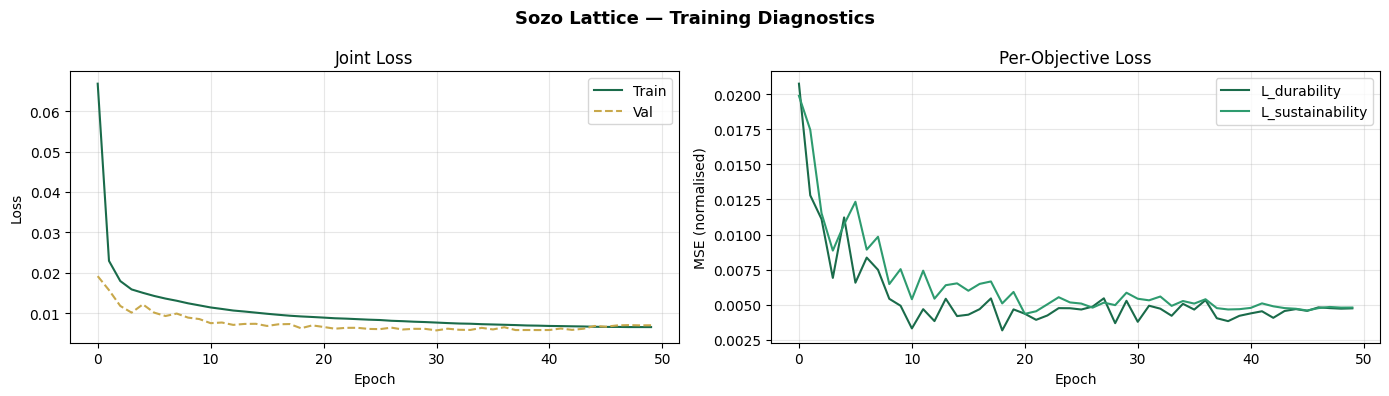

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train'], label='Train', color='#1A6B4A')
axes[0].plot(history['val'],   label='Val',   color='#C8A84B', linestyle='--')
axes[0].set_title('Joint Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['l_dur'], label='L_durability',    color='#1A6B4A')
axes[1].plot(history['l_sus'], label='L_sustainability', color='#2E9B6F')
axes[1].set_title('Per-Objective Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (normalised)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Sozo Lattice — Training Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Phase 5 — MC Dropout Inference

In [23]:
def enable_mc_dropout(m: nn.Module):
    m.eval()
    for layer in m.modules():
        if isinstance(layer, nn.Dropout):
            layer.train()

@torch.no_grad()
def mc_dropout_predict(model, data_obj, n_samples=50):
    enable_mc_dropout(model)
    data_obj = data_obj.to(DEVICE)
    if not hasattr(data_obj, 'batch') or data_obj.batch is None:
        data_obj.batch = torch.zeros(data_obj.x.size(0), dtype=torch.long, device=DEVICE)
    preds = [model(data_obj).cpu().numpy() for _ in range(n_samples)]
    preds = np.array(preds).squeeze()
    if preds.ndim == 1:
        preds = preds[np.newaxis, :]
    return preds.mean(axis=0), preds.std(axis=0)


UNCERTAINTY_THRESHOLD = 5.0

print('MC Dropout inference on 10 validation samples\n')
print(f'{"SMILES":<40} {"Dur μ":>8} {"Dur σ":>7} {"Sus μ":>8} {"Sus σ":>7} {"Flag":<14}')
print('-' * 95)

for i in range(min(10, len(val_data))):
    g    = val_data[i]
    mean, std = mc_dropout_predict(model, g, n_samples=50)
    flag = '⚠️  Experimental' if std[0] > UNCERTAINTY_THRESHOLD else '✅ Confident'
    smi  = df.iloc[i]['smiles']
    smi  = smi[:37] + '...' if len(smi) > 37 else smi
    print(f'{smi:<40} {mean[0]:>8.2f} {std[0]:>7.3f} {mean[1]:>8.4f} {std[1]:>7.4f} {flag}')

MC Dropout inference on 10 validation samples

SMILES                                      Dur μ   Dur σ    Sus μ   Sus σ Flag          
-----------------------------------------------------------------------------------------------
C                                           16.23   8.283   0.7166  0.0423 ⚠️  Experimental
N                                           44.36   3.354   0.5195  0.0277 ✅ Confident
O                                           47.20   2.249   0.5555  0.0130 ✅ Confident
C#C                                         66.89   2.931   0.4575  0.0269 ✅ Confident
C#N                                         81.82   7.157   0.4971  0.0424 ⚠️  Experimental
C=O                                         50.92   3.510   0.5871  0.0322 ✅ Confident
CC                                          55.74   2.542   0.5363  0.0216 ✅ Confident
CO                                          69.58   4.315   0.5183  0.0217 ✅ Confident
CC#C                                        82.86   6.311   0

## Phase 6 — Export Weights

In [25]:
import datetime

DATASET_SOURCES = '+'.join(df['source'].unique().tolist())
TIMESTAMP       = datetime.datetime.now().strftime('%Y%m%d_%H%M')
MODEL_NAME      = f'lattice_v1.0_{TIMESTAMP}'
OUTPUT_DIR      = '/kaggle/working'

# ── Full checkpoint ────────────────────────────────────────────────────────
checkpoint = {
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch':                NUM_EPOCHS,
    'best_val_loss':        best_val,
    'history':              history,
    'config': {
        'node_in_dim':   NODE_FEATURE_DIM,
        'edge_in_dim':   EDGE_FEATURE_DIM,
        'hidden_dim':    128,
        'num_layers':    4,
        'heads':         4,
        'dropout':       0.3,
        'loss_weights':  {'w_durability': 0.4, 'w_sustainability': 0.6},
        'proxy_targets': {
            'durability_score':    'QM9: norm(-U0)×100 | ZINC: norm(logP)×100',
            'sustainability_score':'QM9: 0.6×norm(gap)+0.4×norm(-Cv) | ZINC: 0.5×norm(-logP)+0.3×norm(qed)+0.2×norm(11-SAS)',
        },
        'training_data': DATASET_SOURCES,
        'n_molecules':   len(dataset),
        'stage':         'Stage 0 — proxy labels. Retrain on real lab data for Stage 3.',
    }
}

pt_path = f'{OUTPUT_DIR}/{MODEL_NAME}.pt'
torch.save(checkpoint, pt_path)
print(f'💾 Checkpoint: {pt_path}')

# ── Model Ledger (JSON) ────────────────────────────────────────────────────
ledger = {
    'model_name':         MODEL_NAME,
    'exported_at':        TIMESTAMP,
    'training_data':      DATASET_SOURCES,
    'n_molecules':        len(dataset),
    'architecture':       'GATv2Conv MPNN + Global Attention Pooling',
    'targets':            ['durability_score', 'sustainability_score'],
    'loss_weights':       {'w_durability': 0.4, 'w_sustainability': 0.6},
    'node_feature_dim':   NODE_FEATURE_DIM,
    'edge_feature_dim':   EDGE_FEATURE_DIM,
    'global_feature_dim': 2,
    'best_val_loss':      best_val,
    'proxy_note':         'Stage 0 proxy labels. Replace with real lab measurements in Stage 3.',
    'uncertainty':        {'method': 'MC Dropout', 'n_samples': 50, 'flag_threshold': UNCERTAINTY_THRESHOLD},
}
ledger_path = f'{OUTPUT_DIR}/{MODEL_NAME}_ledger.json'
with open(ledger_path, 'w') as f:
    json.dump(ledger, f, indent=2)
print(f'📋 Ledger:     {ledger_path}')



💾 Checkpoint: /kaggle/working/lattice_v1.0_20260409_1928.pt
📋 Ledger:     /kaggle/working/lattice_v1.0_20260409_1928_ledger.json
